# Cox Proportional Hazard Modeling 2: Gene Expression 
Now, we will do univariate testing of individual gene expression to see which effect survival the most

In [130]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import pyhere as here
from collections import defaultdict

In [131]:
here.here()

PosixPath('/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction')

### Preprocessing Functions

In [132]:
def preprocess_for_cox(df, duration_col, event_col):
    # Drop rows with missing values in duration or event columns
    df = df.dropna(subset=[duration_col, event_col])
    
    # Ensure duration column is numeric
    df[duration_col] = pd.to_numeric(df[duration_col], errors='coerce')
    
    # Drop rows with non-numeric duration values
    df = df.dropna(subset=[duration_col])
    
    return df

In [133]:
# converts float columns with whole numbers to integer type
def convert_whole_float_columns_to_int(df):
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            # Check if all non-null values are whole numbers
            if df[col].dropna().apply(float.is_integer).all():
                df[col] = df[col].astype("Int64")  # nullable integer type
    return df

In [134]:
def one_hot_encode(df, convert_whole_num_ints=True):
    # One hot encode categorical variables

    # Identify categorical columns automatically
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Apply one-hot encoding only to categorical columns
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Change boolean columns to integers
    bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
    
    if convert_whole_num_ints:
        df_encoded = convert_whole_float_columns_to_int(df_encoded)
    return df_encoded

### Load data and Preprocess

In [135]:
# load clinical metadata with PCA + UMAP features
pca_clinical_df = pd.read_csv(here.here("data", "processed","clinical_dimred_features.csv"))

In [136]:
pca_clinical_df["death_from_cancer"].value_counts()

death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
Name: count, dtype: int64

In [137]:
# Set event column early for Cox modeling
pca_clinical_df["event"] = pca_clinical_df["death_from_cancer"].apply(lambda x: 1 if x == "Died of Disease" else 0)

In [138]:
# load expression data
expression_data_df = pd.read_csv(here.here("data", "processed","expression_data.csv"))

In [139]:
df_encoded = one_hot_encode(pca_clinical_df)


In [140]:
df_encoded["event"].value_counts()

event
0    1282
1     622
Name: count, dtype: int64

In [141]:
# One hot encode categorical variables

df_encoded = one_hot_encode(pca_clinical_df)
df_encoded = convert_whole_float_columns_to_int(df_encoded)
# Rename for clarity
df_encoded = df_encoded.rename(columns={
    "overall_survival_months": "time",
    #"death_from_cancer_Living": "event" # already done previously
})

In [142]:
# gene expression data with time and cancer survival columns
survival_exp = pd.concat([df_encoded[["time","event"]], expression_data_df], axis=1)

# Ensure no time = 0 for proportional hazards testing
EPS = 1e-4  # or smaller if time is in months
survival_exp['time_adj'] = survival_exp['time'].clip(lower=EPS)

#### Time = 0 will cause runtime error when log-transforming, so we clip it to a very small number

In [143]:
(survival_exp['time']==0).sum()

np.int64(1)

In [144]:
(survival_exp['time_adj']==0).sum()

np.int64(0)

In [145]:
survival_exp["event"].value_counts()

event
0    1282
1     622
Name: count, dtype: int64

## Screen Genes Individually for Cox Modeling

We will look at each gene individually first, observing which genes violate our proportional hazard assumption

In [146]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

ph_results = []

for gene in expression_data_df.columns:
    print(f"Processing gene: {gene}")
    df_tmp = survival_exp[['time_adj', 'event', gene]].dropna()

    # Skip genes with near-zero variance
    if df_tmp[gene].std() < 1e-6:
        continue

    cph = CoxPHFitter()
    cph.fit(df_tmp, 'time_adj', 'event')

    # Perform proportional hazards test on log time to model early vs late effects better
    ph_test = proportional_hazard_test(cph, df_tmp, time_transform='log')

    ph_results.append({
        'gene': gene,
        'ph_p': ph_test.summary.loc[gene, 'p'],
        'coef': cph.params_[gene],
        'hr': cph.hazard_ratios_[gene],
    })

ph_df = pd.DataFrame(ph_results)
ph_df['ph_violation'] = ph_df['ph_p'] < 0.01



Processing gene: brca1
Processing gene: brca2
Processing gene: palb2
Processing gene: pten
Processing gene: tp53
Processing gene: atm
Processing gene: cdh1
Processing gene: chek2
Processing gene: nbn
Processing gene: nf1
Processing gene: stk11
Processing gene: bard1
Processing gene: mlh1
Processing gene: msh2
Processing gene: msh6
Processing gene: pms2
Processing gene: epcam
Processing gene: rad51c
Processing gene: rad51d
Processing gene: rad50
Processing gene: rb1
Processing gene: rbl1
Processing gene: rbl2
Processing gene: ccna1
Processing gene: ccnb1
Processing gene: cdk1
Processing gene: ccne1
Processing gene: cdk2
Processing gene: cdc25a
Processing gene: ccnd1
Processing gene: cdk4
Processing gene: cdk6
Processing gene: ccnd2
Processing gene: cdkn2a
Processing gene: cdkn2b
Processing gene: myc
Processing gene: cdkn1a
Processing gene: cdkn1b
Processing gene: e2f1
Processing gene: e2f2
Processing gene: e2f3
Processing gene: e2f4
Processing gene: e2f5
Processing gene: e2f6
Processing

### Create time interactions for genes violating porportional hazard

In [147]:
# create interaction terms for genes with proportional hazards violations
violating_genes = ph_df.loc[ph_df.ph_violation, 'gene'].tolist()

df_model = survival_exp.copy()

for gene in violating_genes:
    df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])


/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83658/86578403.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])
/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83658/86578403.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])
/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83658/86578403.py:7: PerformanceWarning: DataFrame is highly fragmented.  Thi

In [148]:
# 23 genes with proportional hazards violations
len(violating_genes)

155

In [149]:
df_model

,time,event,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,...,sdc4_logt,serpini1_logt,sox9_logt,spry2_logt,srd5a1_logt,srd5a3_logt,st7_logt,tnk2_logt,tulp4_logt,ugt2b17_logt
0,140.500000,0,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,...,2.476560,0.025715,6.125134,14.240219,-5.873423,-8.082942,-1.059263,-5.806168,-7.308522,-4.375025
1,84.633333,0,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,...,-0.464693,0.098531,-5.861256,1.085615,-1.958190,1.805512,3.388220,4.048199,-4.233277,2.395810
2,163.700000,1,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,...,-1.814391,-3.943330,6.399054,2.341528,-2.743253,4.253801,8.782386,-18.950418,-7.921328,-0.549568
3,164.933333,0,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-1.1889,...,-0.889385,-1.459164,-4.026740,6.821514,-2.874420,4.200839,3.481469,-11.888764,-5.066739,1.184486
4,41.366667,1,1.2932,-0.9039,-0.7219,0.2168,0.3484,0.3897,0.9131,0.9356,...,-3.307419,-2.064113,0.691636,-1.191564,-2.175787,-3.778313,8.547176,-0.585173,0.158950,14.322596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,0,0.1563,0.5543,-0.6149,0.4572,1.3822,-0.0537,-0.1323,0.2837,...,-10.144036,-0.880597,-8.985050,3.375535,4.151538,5.914317,4.287299,-6.679227,-1.883749,-3.365498
1900,44.733333,1,0.1343,0.9128,1.3017,0.7383,0.1841,0.0028,0.1243,2.2040,...,0.092738,0.687170,1.056600,-3.793117,-2.012101,-0.611916,0.855542,-1.296805,-4.067909,0.243626
1901,175.966667,1,1.8107,-0.2608,0.4006,-0.2985,0.0356,-0.1620,1.5486,1.5309,...,7.438503,3.937696,-7.236861,-6.114907,-0.753312,12.392162,3.059263,-7.001096,-9.345824,0.499967
1902,86.233333,0,-1.2746,-1.7695,-0.3454,-0.3850,0.6689,1.4531,1.0956,-0.0948,...,-3.834406,1.436509,-2.118439,-3.139105,-2.843602,4.933962,0.977878,-3.113254,-2.694737,-1.268924


### Create new model with all genes, including time covariates for genes violating PH

In [150]:
# create interaction terms for genes with proportional hazards violations
violating_genes = ph_df.loc[ph_df.ph_violation, 'gene'].tolist()

df_model = survival_exp.copy()

for gene in violating_genes:
    df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])

# Define model variables
base_genes = ph_df.loc[
    (ph_df.ph_violation == False) & (ph_df.ph_p > 0.05),
    'gene'
].tolist()

# genes without proportional hazards violations
len(base_genes)

/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83658/4270680564.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])
/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83658/4270680564.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])
/var/folders/lg/ycvb06q90x9cty7h1176t0200000gn/T/ipykernel_83658/4270680564.py:7: PerformanceWarning: DataFrame is highly fragmented

301

In [151]:
# create covariates list, combining base genes, violating genes, and their interaction terms
covariates = (
    base_genes +
    violating_genes +
    [f'{g}_logt' for g in violating_genes]
)

In [152]:
# fit new model with interaction terms
# penalizer and l1_ratio are set to balance model complexity and avoid overfitting
cph = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
cph.fit(
    df_model[['time_adj', 'event'] + covariates],
    'time_adj',
    'event'
)

<lifelines.CoxPHFitter: fitted with 1904 total observations, 1282 right-censored observations>

In [153]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1904 total observations, 1282 right-censored observations>
             duration col = 'time_adj'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.5
      baseline estimation = breslow
   number of observations = 1904
number of events observed = 622
   partial log-likelihood = -4369.14
         time fit was run = 2026-05-13 23:00:19 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
brca1          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
brca2         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
palb2          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tp53          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
atm            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdh1          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
stk11          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
pms2          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rad51c        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rad51d        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rad50          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rb1            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdk2           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ccnd2         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdkn2b         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdkn1a         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdkn1b        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
e2f1          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
e2f5           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
e2f6          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
src            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
jak1          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
jak2          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
stat1          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
stat2          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
stat3         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
stat5a        -0.07      0.94      0.04           -0.15            0.02                0.86                1.02
mdm2           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
adam10         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
arrdc1         0.00      1.00      0.00           -0.00            0.00                1.00        

### Model Result
Many genes given coefficient of 0 due to L1 regularization.

### Next steps: 
1. Tune penalizer via k-fold cross validation with an array of penalizer values

In [154]:
from lifelines.utils import k_fold_cross_validation

for p in [0.001, 0.01, 0.05, 0.1]:
    cph = CoxPHFitter(penalizer=p, l1_ratio=0.5)
    scores = k_fold_cross_validation(
        cph,
        df_model[['time_adj', 'event'] + covariates],
        duration_col='time_adj',
        event_col='event',
        k=5,
        scoring_method="concordance_index"
    )
    print(p, np.mean(scores))


0.001 0.6676884381857687
0.01 0.6817729367445413
0.05 0.6858015453481219
0.1 0.6726683875264644


#### *Looks like our best result is 0.05*
Lets run again to report variability between folds as well

In [155]:
for p in [.01, 0.05, 0.1]:
    cph = CoxPHFitter(penalizer=p, l1_ratio=0.5)
    scores = k_fold_cross_validation(
        cph,
        df_model[['time_adj', 'event'] + covariates],
        duration_col='time_adj',
        event_col='event',
        k=5,
        scoring_method="concordance_index"
    )
    print(p, np.mean(scores), np.std(scores))


0.01 0.6805186963575378 0.028835427692327862
0.05 0.6815062747077406 0.02872177917456933
0.1 0.6725880836497903 0.02914394831112372


In [156]:
# now, we refit the model with genes only with the best penalizer
cph_final = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)
cph_final.fit(
    df_model[['time_adj', 'event'] + covariates],
    'time_adj',
    'event'
)

<lifelines.CoxPHFitter: fitted with 1904 total observations, 1282 right-censored observations>

In [157]:
pd.set_option('display.max_rows', 100) # Show all rows

cph_final.summary.sort_values("coef", key=abs, ascending=False)[:15]

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
aurka,0.186931,1.205544,0.066260,0.057063,0.316799,1.058722,1.372726,0.0,2.821151,0.004785,7.707214
mapt,-0.096745,0.907787,0.054994,-0.204532,0.011042,0.815029,1.011103,0.0,-1.759179,0.078547,3.670299
stat5a,-0.092189,0.911933,0.048368,-0.186988,0.002610,0.829453,1.002614,0.0,-1.905993,0.056651,4.141753
nr2f1,0.076998,1.080039,0.043695,-0.008643,0.162638,0.991394,1.176611,0.0,1.762164,0.078042,3.679613
gsk3b,0.075777,1.078723,0.051352,-0.024871,0.176426,0.975436,1.192946,0.0,1.475641,0.140040,2.836085
ccnb1,0.070802,1.073369,0.058220,-0.043307,0.184911,0.957617,1.203112,0.0,1.216114,0.223941,2.158807
igf1r,-0.069343,0.933007,0.053635,-0.174466,0.035780,0.839905,1.036428,0.0,-1.292864,0.196058,2.350646
stat5b,-0.046309,0.954747,0.050204,-0.144707,0.052089,0.865276,1.053469,0.0,-0.922423,0.356308,1.488803
diras3,-0.044563,0.956415,0.047975,-0.138593,0.049467,0.870582,1.050711,0.0,-0.928875,0.352954,1.502448


### Here, by sorting for coefficient absolute value, we can determine which genes are actually predictive of survival and which are "zeroed out" due to regularization. For the final model, we will pick clinical variables with coef > abs(0.05)

# Clinical + Gene Expression Model
## Next, we will combine all of our covariates (both clinical and gene expression) into a single model, and determine which features are most predictive

In [158]:
# add clinical features from clinical modeling notebook
clinical_cols = [
    # "overall_survival_months",   # time (already included as time_adj )
    # "death_from_cancer",         # event (already included in df_model)
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

In [159]:
# To do: preprocess clinical data, add this to model with gene expression, refit model, and bootstrap 

# clinical data for modeling
clinical_selected = pca_clinical_df[clinical_cols]

df_encoded = one_hot_encode(clinical_selected)
df_encoded = convert_whole_float_columns_to_int(df_encoded)
# Rename for clarity
df_encoded = df_encoded.rename(columns={
    "overall_survival_months": "time",
    "death_from_cancer_Living": "event"
})

In [160]:
# reduce gene expression data to only include abs(coef) > 0.05 from final model
# active_set = cph_final.summary.sort_values("coef", key=abs, ascending=False)[:13].index.tolist()
# active_set

In [161]:
# combine clinical and gene expression data. First, we will try it with all gene expression features
df_combined = pd.concat([df_encoded, df_model[['time_adj', 'event'] +  covariates]],axis=1)

In [162]:
# remove rows with missing data
df_combined.dropna(inplace=True)

In [163]:
# dataset with clinical and expression data
df_combined

,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,...,sdc4_logt,serpini1_logt,sox9_logt,spry2_logt,srd5a1_logt,srd5a3_logt,st7_logt,tnk2_logt,tulp4_logt,ugt2b17_logt
0,75.65,22.0,10,3,0,1,1,0,0,0,...,2.476560,0.025715,6.125134,14.240219,-5.873423,-8.082942,-1.059263,-5.806168,-7.308522,-4.375025
1,43.19,10.0,0,3,0,1,1,1,0,1,...,-0.464693,0.098531,-5.861256,1.085615,-1.958190,1.805512,3.388220,4.048199,-4.233277,2.395810
2,48.87,15.0,1,2,1,0,1,1,0,1,...,-1.814391,-3.943330,6.399054,2.341528,-2.743253,4.253801,8.782386,-18.950418,-7.921328,-0.549568
3,47.68,25.0,3,2,1,1,1,1,0,1,...,-0.889385,-1.459164,-4.026740,6.821514,-2.874420,4.200839,3.481469,-11.888764,-5.066739,1.184486
4,76.97,40.0,8,3,1,1,1,1,0,0,...,-3.307419,-2.064113,0.691636,-1.191564,-2.175787,-3.778313,8.547176,-0.585173,0.158950,14.322596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,25.0,1,3,0,1,1,1,0,1,...,-10.144036,-0.880597,-8.985050,3.375535,4.151538,5.914317,4.287299,-6.679227,-1.883749,-3.365498
1900,42.88,20.0,1,3,0,1,1,0,1,1,...,0.092738,0.687170,1.056600,-3.793117,-2.012101,-0.611916,0.855542,-1.296805,-4.067909,0.243626
1901,62.90,25.0,45,3,0,1,1,1,0,0,...,7.438503,3.937696,-7.236861,-6.114907,-0.753312,12.392162,3.059263,-7.001096,-9.345824,0.499967
1902,61.16,25.0,12,2,0,0,1,1,0,0,...,-3.834406,1.436509,-2.118439,-3.139105,-2.843602,4.933962,0.977878,-3.113254,-2.694737,-1.268924


## Fit model with all gene expression + clinical features

In [164]:
# Fit model
cph = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)
cph.fit(
    df_combined,
    duration_col='time_adj',
    event_col='event', 
    strata=["chemotherapy", "radio_therapy"] # stratify by treatment variables to account for their effects on baseline hazard
)

<lifelines.CoxPHFitter: fitted with 1815 total observations, 1214 right-censored observations>

In [165]:
cph.print_summary()

model,lifelines.CoxPHFitter
duration col,'time_adj'
event col,'event'
penalizer,0.05
l1 ratio,0.5
strata,"[chemotherapy, radio_therapy]"
baseline estimation,breslow
number of observations,1815
number of events observed,601
partial log-likelihood,-3361.89
time fit was run,2026-05-14 00:04:27 UTC


## Bootstrap 
We will now bootstrap the data to test the stability of the model. 
To do this, we will keep all clinical covariates in the data, and bootstrap gene expression data to see which genes are most stable and predictive

In [166]:
# define values in dataframe
SURVIVAL_COLS = ["time_adj", "event"]
STRATA_COLS = ["chemotherapy", "radio_therapy"]

clinical_cols = [
    # "overall_survival_months",   # time (already included as time_adj )
    # "death_from_cancer",         # event (already included in df_model)
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

gene_cols = [
    c for c in df_combined.columns
    if c not in SURVIVAL_COLS + STRATA_COLS + clinical_cols
]


In [167]:
len(gene_cols), len(clinical_cols)

(621, 11)

In [168]:
cph = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)

cph.fit(
    df_combined,
    duration_col="time_adj",
    event_col="event",
    strata=STRATA_COLS
)

final_coefs = cph.params_


## Setup bootstrap
We will start with 200 bootstraps (random sampling with replacement) to determine the most stable and predictive genes

In [169]:
n_bootstraps = 200
ACTIVE_PERCENTILE = 95   # top 5% strongest genes per bootstrap

selection_counts = defaultdict(int)
signs = defaultdict(list)

np.random.seed(42)

In [ ]:
for b in range(n_bootstraps):

    # Resample patients with replacement
    boot_idx = np.random.choice(
        df_combined.index,
        size=len(df_combined),
        replace=True
    )
    df_boot = df_combined.loc[boot_idx]

    # penalizer incrased to improve convergence in bootstrapping
    cph_boot = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)

    try:
        cph_boot.fit(
            df_boot,
            duration_col="time_adj",
            event_col="event",
            strata=STRATA_COLS
        )
    except Exception:
        continue  # convergence failures are OK in bootstrapping

    boot_coefs = cph_boot.params_

    # ---- IMPORTANT PART ----
    # Only genes participate in active-set definition
    gene_coefs = boot_coefs.loc[gene_cols].dropna()
    abs_gene_coefs = gene_coefs.abs()

    if len(abs_gene_coefs) == 0:
        continue

    threshold = np.percentile(abs_gene_coefs, ACTIVE_PERCENTILE)
    active_genes = abs_gene_coefs[abs_gene_coefs >= threshold]

    for gene in active_genes.index:
        selection_counts[gene] += 1
        signs[gene].append(np.sign(gene_coefs[gene]))

    if (b+1) % 10 == 0:
        print(f"Completed bootstrap {b+1}/{n_bootstraps}")


In [ ]:
stability_df = pd.DataFrame({
    "selection_freq": {
        g: selection_counts[g] / n_bootstraps
        for g in gene_cols
    },
    "sign_consistency": {
        g: (
            np.mean(np.sign(final_coefs[g]) == np.array(signs[g]))
            if len(signs[g]) > 0 else np.nan
        )
        for g in gene_cols
    },
    "final_coef": final_coefs.loc[gene_cols]
})


In [ ]:
stable_genes = stability_df[
    (stability_df["selection_freq"] >= 0.6) &
    (stability_df["sign_consistency"] >= 0.9)
].sort_values("selection_freq", ascending=False)


In [ ]:
stable_genes

,selection_freq,sign_consistency,final_coef
pdpk1,0.890,1.0,0.111229
arid1a,0.890,1.0,0.098087
cxcr1,0.820,1.0,0.095469
rb1,0.815,1.0,0.070182
hsd17b11,0.805,1.0,0.130336
sf3b1,0.790,1.0,0.100282
star,0.695,1.0,0.060520
tsc1,0.685,1.0,-0.063734
acvr1b,0.620,1.0,0.055351


### Results: 200 bootstraps took too long to converge, so we will try a new method

In [ ]:
# define values in dataframe
SURVIVAL_COLS = ["time_adj", "event"]
STRATA_COLS = ["chemotherapy", "radio_therapy"]

# Required columns
TIME_COL = "time_adj"
EVENT_COL = "event"

clinical_cols = [
    # "overall_survival_months",   # time (already included as time_adj )
    # "death_from_cancer",         # event (already included in df_model)
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

gene_cols = [
    c for c in df_combined.columns
    if c not in SURVIVAL_COLS + STRATA_COLS + clinical_cols
]

In [ ]:
# global parameters for bootstrapping

N_BOOTSTRAPS = 100
PENALIZER = 0.2
L1_RATIO = 0.5
ACTIVE_SET_PERCENTILE = 95
GENE_VAR_THRESHOLD = 0.3


In [ ]:
# filter genes by variance threshold
gene_vars = df_combined[gene_cols].var()
gene_cols = gene_vars[gene_vars > GENE_VAR_THRESHOLD].index.tolist()

print(f"Genes retained after filtering: {len(gene_cols)} out of {len(gene_cols)}")


Genes retained after filtering: 481 out of 481


In [ ]:
# define modeling dataframe
# model_cols = (
#     [TIME_COL, EVENT_COL]
#     + clinical_cols
#     + gene_cols
# )

# we retain the complete dataset
df_model = df_combined

In [ ]:
# create function for single bootstrap run
import numpy as np
from lifelines import CoxPHFitter

def run_single_bootstrap(seed):
    np.random.seed(seed)

    # Resample patients
    boot_idx = np.random.randint(0, len(df_model), len(df_model))
    df_boot = df_model.iloc[boot_idx]

    cph = CoxPHFitter(
        penalizer=PENALIZER,
        l1_ratio=L1_RATIO, 
        strata=STRATA_COLS
    )

    try:
        cph.fit(
            df_boot,
            duration_col=TIME_COL,
            event_col=EVENT_COL
        )
    except Exception:
        return None

    # Extract gene coefficients only
    coefs = cph.params_.loc[gene_cols].dropna()

    if coefs.empty:
        return None

    abs_coefs = coefs.abs()
    threshold = np.percentile(abs_coefs, ACTIVE_SET_PERCENTILE)

    active_genes = abs_coefs[abs_coefs >= threshold].index.tolist()

    return {
        "genes": active_genes,
        "signs": np.sign(coefs.loc[active_genes]).to_dict()
    }

In [ ]:
# paralelize bootstrapping

from joblib import Parallel, delayed

results = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    delayed(run_single_bootstrap)(i)
    for i in range(N_BOOTSTRAPS)
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  3.3min
/Users/jmakings/miniforge3/envs/bc_survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['pam50_+_claudin-low_subtype_NC'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/jmakings/miniforge3/envs/bc_survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:797: RuntimeWarning: invalid value encountered in divide
  return (X - mean) / std
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed: 10.4min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 17.1min
[Paralle

In [ ]:
# aggregate results

from collections import defaultdict

selection_counts = defaultdict(int)
signs = defaultdict(list)

for res in results:
    if res is None:
        continue
    for g in res["genes"]:
        selection_counts[g] += 1
        signs[g].append(res["signs"][g])

# Convert to dataframe
import pandas as pd

stability_df = pd.DataFrame({
    "gene": list(selection_counts.keys()),
    "selection_frequency": [
        selection_counts[g] / N_BOOTSTRAPS
        for g in selection_counts
    ],
    "sign_consistency": [
        abs(np.mean(signs[g]))
        for g in selection_counts
    ]
}).sort_values("selection_frequency", ascending=False)


In [ ]:
# final stable gene set
stable_genes = stability_df[
    (stability_df["selection_frequency"] >= 0.25) &
    (stability_df["sign_consistency"] >= 0.8)
]

print(f"Stable genes selected: {len(stable_genes)}")


Stable genes selected: 29


In [ ]:
stable_genes

,gene,selection_frequency,sign_consistency
2,jak1,0.98,1.0
24,sf3b1_logt,0.98,1.0
23,sf3b1,0.98,1.0
1,rb1,0.98,1.0
11,pdpk1,0.98,1.0
18,hsd17b11,0.98,1.0
16,kmt2c,0.97,1.0
22,casp8,0.96,1.0
15,arid1a,0.93,1.0
21,ran,0.89,1.0


In [ ]:
stable_genes_list = stable_genes["gene"].tolist()
stable_genes_list.remove('sf3b1')

In [ ]:
stable_genes_list

['jak1',
 'sf3b1_logt',
 'rb1',
 'pdpk1',
 'hsd17b11',
 'kmt2c',
 'casp8',
 'arid1a',
 'ran',
 'myc',
 'hsd3b7',
 'tgfbr2',
 'mlh1',
 'tnk2',
 'smad7',
 'ep300',
 'akt1s1',
 'casp6',
 'stat3',
 'folr2',
 'stat2',
 'adam17',
 'tsc1',
 'maml3',
 'cxcr1',
 'casp10',
 'ubr5',
 'smad2']

In [ ]:
df_combined.iloc[:,:18]

,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,pam50_+_claudin-low_subtype_Her2,pam50_+_claudin-low_subtype_LumA,pam50_+_claudin-low_subtype_LumB,pam50_+_claudin-low_subtype_NC,pam50_+_claudin-low_subtype_Normal,pam50_+_claudin-low_subtype_claudin-low,time_adj,event
0,75.65,22.0,10,3,0,1,1,0,0,0,0,0,0,0,0,1,140.500000,1
1,43.19,10.0,0,3,0,1,1,1,0,1,0,1,0,0,0,0,84.633333,1
2,48.87,15.0,1,2,1,0,1,1,0,1,0,0,1,0,0,0,163.700000,0
3,47.68,25.0,3,2,1,1,1,1,0,1,0,0,1,0,0,0,164.933333,1
4,76.97,40.0,8,3,1,1,1,1,0,0,0,0,1,0,0,0,41.366667,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,25.0,1,3,0,1,1,1,0,1,0,1,0,0,0,0,196.866667,1
1900,42.88,20.0,1,3,0,1,1,0,1,1,0,0,1,0,0,0,44.733333,0
1901,62.90,25.0,45,3,0,1,1,1,0,0,0,0,1,0,0,0,175.966667,0
1902,61.16,25.0,12,2,0,0,1,1,0,0,0,0,1,0,0,0,86.233333,0


In [ ]:
df_combined.loc[:,stable_genes_list]

,jak1,sf3b1_logt,rb1,pdpk1,hsd17b11,kmt2c,casp8,arid1a,ran,myc,...,stat3,folr2,stat2,adam17,tsc1,maml3,cxcr1,casp10,ubr5,smad2
0,1.1097,0.050936,-0.2770,-0.2005,1.6822,-0.9045,0.1816,-1.2999,0.6630,2.5602,...,0.9765,1.0893,-0.7556,0.8721,0.0623,-1.5365,0.9278,0.3033,-1.6059,0.7905
1,0.9804,11.189025,-1.7488,0.2841,-0.7837,-0.0208,1.8819,1.9157,-0.2505,0.7248,...,-0.8428,-0.9169,-0.7991,-0.2006,0.8054,-0.1651,-1.2491,0.1039,0.5109,1.1109
2,1.5835,-3.358586,1.4142,-0.4960,1.6822,-0.5063,0.6432,-0.9847,0.2707,-0.7207,...,-0.2243,0.5313,-1.3487,-1.1229,-0.9652,-0.6574,0.0089,-0.8205,0.4933,-1.0038
3,0.6194,-3.163904,1.5345,-0.7175,1.4099,-1.2840,-1.1012,-1.5992,1.7962,-0.5237,...,-1.2401,1.3413,-0.5512,-1.0490,-0.6103,-0.8255,-0.0706,1.2658,1.6069,0.4072
4,0.0461,3.872119,1.0158,1.4198,0.0493,-1.1026,1.8931,0.5634,1.2930,0.5223,...,-0.5049,0.6556,0.3308,-0.2383,-0.7420,-2.1710,-0.9502,0.1754,3.1012,-0.7546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,1.3329,7.771653,1.1341,-0.0361,1.5955,-0.7792,1.7063,-0.7148,1.4046,0.4000,...,1.0668,1.0170,-0.9786,-0.3600,-0.2158,-0.4006,-0.6513,-0.0163,-0.5414,-0.0048
1900,-0.1851,-1.010611,0.4500,1.7397,0.2741,-0.9098,-0.2765,-0.9123,0.8469,-0.0430,...,-0.8253,-0.1741,-1.4386,0.3862,0.1450,-1.3119,0.4195,-1.6358,0.2799,0.2265
1901,0.5161,5.470689,0.9070,0.7885,0.3877,-0.3638,2.3513,-0.8813,2.1818,2.0526,...,0.3966,-0.0257,-1.6392,0.1968,-1.6078,-1.6289,-0.1224,1.9447,0.8791,0.5264
1902,1.2830,7.010059,0.0080,1.6513,0.6109,-0.4029,2.9647,0.5087,1.3851,0.0151,...,-1.1179,0.5692,-0.9625,0.2951,0.2223,-0.3767,-0.4862,1.4720,-0.9971,-0.6755


In [ ]:
# UPDDATE: Neoplasm histologic grade data is reversed, so we will flip it to match expected ordering (grade 1 = well differentiated, grade 3 = poorly differentiated)
df_combined["neoplasm_histologic_grade"] = (
    df_combined["neoplasm_histologic_grade"]
    .map({1: 3, 2: 2, 3: 1})
)

# final model with clinical covariates + stable genes

final_covariates = (
    list(df_combined.iloc[:,:16].columns) +
    stable_genes_list
)

final_df = df_combined[
    [TIME_COL, EVENT_COL] + final_covariates
].dropna()

final_cph = CoxPHFitter(penalizer=0.01)
final_cph.fit(
    final_df,
    duration_col=TIME_COL,
    event_col=EVENT_COL, 
    strata=STRATA_COLS
)

final_cph.print_summary()


model,lifelines.CoxPHFitter
duration col,'time_adj'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,"[chemotherapy, radio_therapy]"
baseline estimation,breslow
number of observations,1815
number of events observed,774
partial log-likelihood,-3682.52
time fit was run,2026-05-12 20:41:04 UTC


# Plots showcasing model findings

## Forest Plot of Top Coefficients
#### Most predictive coefficients in final cox model

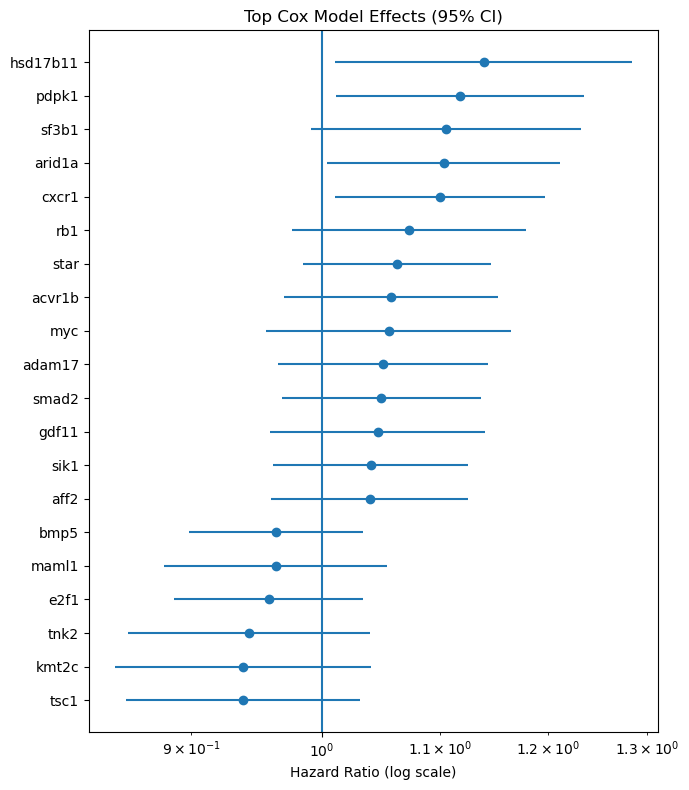

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract summary table
summary = cph.summary.copy()

# Select strongest effects (by absolute z-score)
top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(20)
    .sort_values("coef")
)

plt.figure(figsize=(7, 8))
plt.errorbar(
    top["exp(coef)"],
    top.index,
    xerr=[
        top["exp(coef)"] - top["exp(coef) lower 95%"],
        top["exp(coef) upper 95%"] - top["exp(coef)"],
    ],
    fmt="o"
)

plt.axvline(1.0)
plt.xlabel("Hazard Ratio (log scale)")
plt.xscale("log")
plt.title("Top Cox Model Effects (95% CI)")
plt.tight_layout()
plt.show()


In [ ]:
summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
age_at_diagnosis,-2.286072e-10,1.0,0.000001,-0.000003,0.000003,0.999997,1.000003,0.0,-0.000155,0.999877,0.000178
tumor_size,-8.594727e-10,1.0,0.000002,-0.000003,0.000003,0.999997,1.000003,0.0,-0.000516,0.999588,0.000594
lymph_nodes_examined_positive,-1.341394e-09,1.0,0.000005,-0.000010,0.000010,0.999990,1.000010,0.0,-0.000275,0.999780,0.000317
neoplasm_histologic_grade,-4.561731e-08,1.0,0.000093,-0.000182,0.000181,0.999818,1.000181,0.0,-0.000493,0.999607,0.000567
er_status_Positive,-3.998973e-09,1.0,0.000045,-0.000088,0.000088,0.999912,1.000088,0.0,-0.000089,0.999929,0.000103
...,...,...,...,...,...,...,...,...,...,...,...
sf3b1_logt,3.524839e-09,1.0,0.000006,-0.000012,0.000012,0.999988,1.000012,0.0,0.000556,0.999556,0.000641
smarcc1_logt,-4.016021e-09,1.0,0.000007,-0.000014,0.000014,0.999986,1.000014,0.0,-0.000568,0.999547,0.000654
tbl1xr1_logt,1.785851e-09,1.0,0.000005,-0.000009,0.000009,0.999991,1.000009,0.0,0.000384,0.999693,0.000443


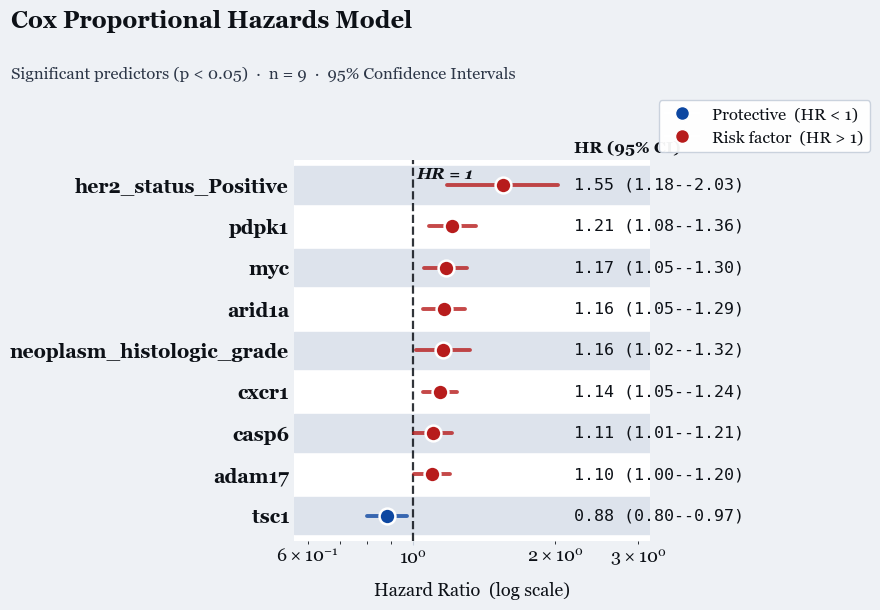

Saved -> cox_forest_plot_styled.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Style config ───────────────────────────────────────────────────────────────
BACKGROUND   = "#EEF1F5"
PANEL_BG     = "#FFFFFF"
GRID_COLOR   = "#C8D0DC"
TEXT_DARK    = "#0D1117"
TEXT_MUTED   = "#2D3748"
ACCENT_POS   = "#b71c1c"
ACCENT_NEG   = "#0d47a1"
REFLINE      = "#0D1117"

plt.rcParams.update({
    "font.family":        "Georgia",
    "font.size":          14,
    "axes.facecolor":     PANEL_BG,
    "figure.facecolor":   BACKGROUND,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "xtick.color":        TEXT_DARK,
    "ytick.color":        TEXT_DARK,
    "xtick.labelsize":    13,
    "ytick.labelsize":    14,
})

# ── Data prep ─────────────────────────────────────────────────────────────────
summary = final_cph.summary.copy()

top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(10)
    .loc[lambda df: df["p"] < 0.05]   # keep only significant rows
    .sort_values("coef")
)

# guard: nothing to plot if no significant results
if top.empty:
    print("No significant predictors (p < 0.05) found.")
else:
    hr      = top["exp(coef)"].values
    hr_lo   = top["exp(coef) lower 95%"].values
    hr_hi   = top["exp(coef) upper 95%"].values
    names   = top.index.tolist()
    n       = len(names)
    y_pos   = np.arange(n)

    point_colors = [ACCENT_NEG if h < 1 else ACCENT_POS for h in hr]

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, max(4, n * 0.7)))  # height scales with n rows
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(PANEL_BG)

    for i in y_pos:
        ax.axhspan(i - 0.45, i + 0.45,
                   color="#DDE3EC" if i % 2 == 0 else PANEL_BG,
                   zorder=0)

    ax.axvline(1.0, color=REFLINE, linewidth=1.6,
               linestyle="--", zorder=2, alpha=0.85)
    ax.text(1.02, n - 0.55, "HR = 1", color=REFLINE,
            fontsize=12, style="italic", va="top", fontweight="bold")

    for i, (lo, hi, y, col) in enumerate(zip(hr_lo, hr_hi, y_pos, point_colors)):
        ax.plot([lo, hi], [y, y], color=col, linewidth=2.8,
                solid_capstyle="round", zorder=3, alpha=0.8)

    for y, h, col in zip(y_pos, hr, point_colors):
        ax.scatter(h, y, color=col, s=130, zorder=4,
                   edgecolors="white", linewidths=1.8)

    x_label_pos = hr_hi.max() * 1.08
    for y, h, lo, hi in zip(y_pos, hr, hr_lo, hr_hi):
        label = f"{h:.2f} ({lo:.2f}--{hi:.2f})"
        ax.text(x_label_pos, y, label,
                va="center", ha="left",
                fontsize=12, color=TEXT_DARK,
                fontfamily="monospace")

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xscale("log")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=14, color=TEXT_DARK, fontweight="bold")
    ax.set_xlabel("Hazard Ratio  (log scale)", fontsize=13,
                  color=TEXT_DARK, labelpad=10)
    ax.set_ylim(-0.6, n - 0.4)
    ax.tick_params(axis="x", length=3, color=GRID_COLOR)
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(hr_lo.min() * 0.7, x_label_pos * 1.45)

    ax.text(x_label_pos, n - 0.3, "HR (95% CI)",
            va="bottom", ha="left",
            fontsize=12, color=TEXT_DARK, fontweight="bold")

    # ── Title block ───────────────────────────────────────────────────────────
    fig.text(0.02, 0.97, "Cox Proportional Hazards Model",
             fontsize=17, fontweight="bold", color=TEXT_DARK, va="top")
    fig.text(0.02, 0.88, f"Significant predictors (p < 0.05)  ·  n = {n}  ·  95% Confidence Intervals",
             fontsize=12, color=TEXT_MUTED, va="top")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_NEG,
               markersize=10, label="Protective  (HR < 1)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_POS,
               markersize=10, label="Risk factor  (HR > 1)"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower left",
        bbox_to_anchor=(1.0, 1.0),    # top-right corner, outside axes
        bbox_transform=ax.transAxes,
        frameon=True,
        framealpha=0.95,
        edgecolor=GRID_COLOR,
        fontsize=12,
        labelcolor=TEXT_DARK,
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.86])  # shrink right edge to make room
    plt.savefig("cox_forest_plot_styled.png", dpi=180, bbox_inches="tight",
                facecolor=BACKGROUND)
    plt.show()
    print("Saved -> cox_forest_plot_styled.png")

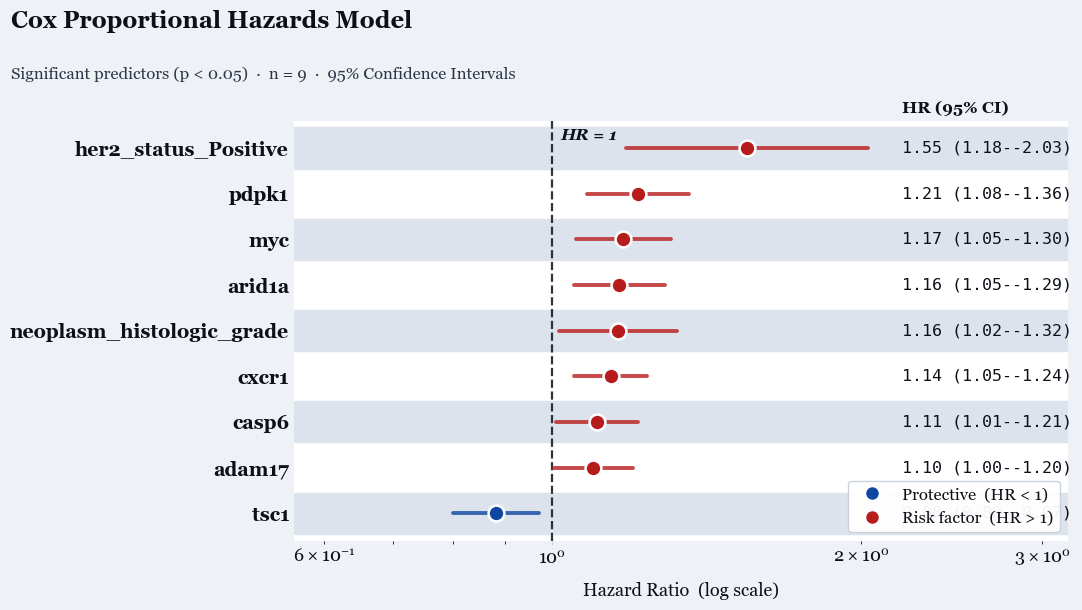

Saved -> cox_forest_plot_styled.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Style config ───────────────────────────────────────────────────────────────
BACKGROUND   = "#EEF1F5"
PANEL_BG     = "#FFFFFF"
GRID_COLOR   = "#C8D0DC"
TEXT_DARK    = "#0D1117"
TEXT_MUTED   = "#2D3748"
ACCENT_POS   = "#b71c1c"
ACCENT_NEG   = "#0d47a1"
REFLINE      = "#0D1117"

plt.rcParams.update({
    "font.family":        "Georgia",
    "font.size":          14,
    "axes.facecolor":     PANEL_BG,
    "figure.facecolor":   BACKGROUND,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "xtick.color":        TEXT_DARK,
    "ytick.color":        TEXT_DARK,
    "xtick.labelsize":    13,
    "ytick.labelsize":    14,
})

# ── Data prep ─────────────────────────────────────────────────────────────────
summary = final_cph.summary.copy()

top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(10)
    .loc[lambda df: df["p"] < 0.05]   # keep only significant rows
    .sort_values("coef")
)

# guard: nothing to plot if no significant results
if top.empty:
    print("No significant predictors (p < 0.05) found.")
else:
    hr      = top["exp(coef)"].values
    hr_lo   = top["exp(coef) lower 95%"].values
    hr_hi   = top["exp(coef) upper 95%"].values
    names   = top.index.tolist()
    n       = len(names)
    y_pos   = np.arange(n)

    point_colors = [ACCENT_NEG if h < 1 else ACCENT_POS for h in hr]

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, max(2, n * 0.7)))  # height scales with n rows
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(PANEL_BG)

    for i in y_pos:
        ax.axhspan(i - 0.45, i + 0.45,
                   color="#DDE3EC" if i % 2 == 0 else PANEL_BG,
                   zorder=0)

    ax.axvline(1.0, color=REFLINE, linewidth=1.6,
               linestyle="--", zorder=2, alpha=0.85)
    ax.text(1.02, n - 0.55, "HR = 1", color=REFLINE,
            fontsize=12, style="italic", va="top", fontweight="bold")

    for i, (lo, hi, y, col) in enumerate(zip(hr_lo, hr_hi, y_pos, point_colors)):
        ax.plot([lo, hi], [y, y], color=col, linewidth=2.8,
                solid_capstyle="round", zorder=3, alpha=0.8)

    for y, h, col in zip(y_pos, hr, point_colors):
        ax.scatter(h, y, color=col, s=130, zorder=4,
                   edgecolors="white", linewidths=1.8)

    x_label_pos = hr_hi.max() * 1.08
    for y, h, lo, hi in zip(y_pos, hr, hr_lo, hr_hi):
        label = f"{h:.2f} ({lo:.2f}--{hi:.2f})"
        ax.text(x_label_pos, y, label,
                va="center", ha="left",
                fontsize=12, color=TEXT_DARK,
                fontfamily="monospace")

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xscale("log")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=14, color=TEXT_DARK, fontweight="bold")
    ax.set_xlabel("Hazard Ratio  (log scale)", fontsize=13,
                  color=TEXT_DARK, labelpad=10)
    ax.set_ylim(-0.6, n - 0.4)
    ax.tick_params(axis="x", length=3, color=GRID_COLOR)
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(hr_lo.min() * 0.7, x_label_pos * 1.45)

    ax.text(x_label_pos, n - 0.3, "HR (95% CI)",
            va="bottom", ha="left",
            fontsize=12, color=TEXT_DARK, fontweight="bold")

    # ── Title block ───────────────────────────────────────────────────────────
    fig.text(0.02, 0.97, "Cox Proportional Hazards Model",
             fontsize=17, fontweight="bold", color=TEXT_DARK, va="top")
    fig.text(0.02, 0.88, f"Significant predictors (p < 0.05)  ·  n = {n}  ·  95% Confidence Intervals",
             fontsize=12, color=TEXT_MUTED, va="top")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_NEG,
               markersize=10, label="Protective  (HR < 1)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_POS,
               markersize=10, label="Risk factor  (HR > 1)"),
    ]
    ax.legend(handles=legend_elements, loc="lower right",
              frameon=True, framealpha=0.95,
              edgecolor=GRID_COLOR, fontsize=12,
              labelcolor=TEXT_DARK)

    plt.tight_layout(rect=[0, 0, 1, 0.86])
    plt.savefig("cox_forest_plot_styled.png", dpi=180, bbox_inches="tight",
                facecolor=BACKGROUND)
    plt.show()
    print("Saved -> cox_forest_plot_styled.png")

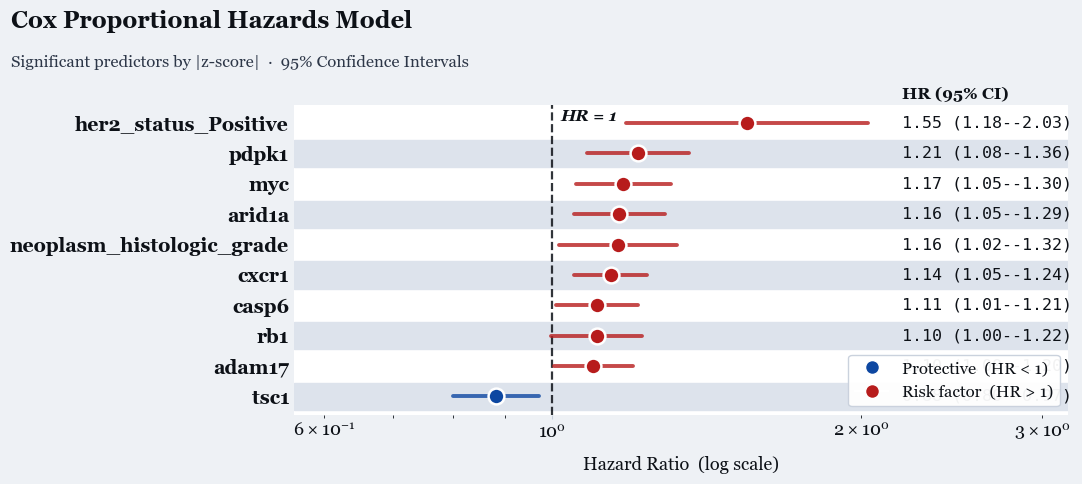

Saved -> cox_forest_plot_styled.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Style config ───────────────────────────────────────────────────────────────
BACKGROUND   = "#EEF1F5"
PANEL_BG     = "#FFFFFF"
GRID_COLOR   = "#C8D0DC"
TEXT_DARK    = "#0D1117"
TEXT_MUTED   = "#2D3748"
ACCENT_POS   = "#b71c1c"
ACCENT_NEG   = "#0d47a1"
REFLINE      = "#0D1117"

plt.rcParams.update({
    "font.family":        "Georgia",
    "font.size":          14,
    "axes.facecolor":     PANEL_BG,
    "figure.facecolor":   BACKGROUND,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "xtick.color":        TEXT_DARK,
    "ytick.color":        TEXT_DARK,
    "xtick.labelsize":    13,
    "ytick.labelsize":    14,
})

# ── Data prep ─────────────────────────────────────────────────────────────────
summary = final_cph.summary.copy()

top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(10)
    .sort_values("coef")
)

hr      = top["exp(coef)"].values
hr_lo   = top["exp(coef) lower 95%"].values
hr_hi   = top["exp(coef) upper 95%"].values
names   = top.index.tolist()
n       = len(names)
y_pos   = np.arange(n)

point_colors = [ACCENT_NEG if h < 1 else ACCENT_POS for h in hr]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(PANEL_BG)

for i in y_pos:
    ax.axhspan(i - 0.45, i + 0.45,
               color="#DDE3EC" if i % 2 == 0 else PANEL_BG,
               zorder=0)

ax.axvline(1.0, color=REFLINE, linewidth=1.6,
           linestyle="--", zorder=2, alpha=0.85)
ax.text(1.02, n - 0.55, "HR = 1", color=REFLINE,
        fontsize=12, style="italic", va="top", fontweight="bold")

for i, (lo, hi, y, col) in enumerate(zip(hr_lo, hr_hi, y_pos, point_colors)):
    ax.plot([lo, hi], [y, y], color=col, linewidth=2.8,
            solid_capstyle="round", zorder=3, alpha=0.8)

for y, h, col in zip(y_pos, hr, point_colors):
    ax.scatter(h, y, color=col, s=130, zorder=4,
               edgecolors="white", linewidths=1.8)

x_label_pos = hr_hi.max() * 1.08
for y, h, lo, hi in zip(y_pos, hr, hr_lo, hr_hi):
    label = f"{h:.2f} ({lo:.2f}--{hi:.2f})"
    ax.text(x_label_pos, y, label,
            va="center", ha="left",
            fontsize=12, color=TEXT_DARK,
            fontfamily="monospace")

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=14, color=TEXT_DARK, fontweight="bold")
ax.set_xlabel("Hazard Ratio  (log scale)", fontsize=13,
              color=TEXT_DARK, labelpad=10)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="x", length=3, color=GRID_COLOR)
ax.tick_params(axis="y", length=0)
ax.set_xlim(hr_lo.min() * 0.7, x_label_pos * 1.45)

ax.text(x_label_pos, n - 0.3, "HR (95% CI)",
        va="bottom", ha="left",
        fontsize=12, color=TEXT_DARK, fontweight="bold")

# ── Title block ───────────────────────────────────────────────────────────────
fig.text(0.02, 0.97, "Cox Proportional Hazards Model",
         fontsize=17, fontweight="bold", color=TEXT_DARK, va="top")
fig.text(0.02, 0.88, "Significant predictors by |z-score|  ·  95% Confidence Intervals",
         fontsize=12, color=TEXT_MUTED, va="top")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_NEG,
           markersize=10, label="Protective  (HR < 1)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_POS,
           markersize=10, label="Risk factor  (HR > 1)"),
]
ax.legend(handles=legend_elements, loc="lower right",
          frameon=True, framealpha=0.95,
          edgecolor=GRID_COLOR, fontsize=12,
          labelcolor=TEXT_DARK)

plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.savefig("cox_forest_plot_styled.png", dpi=180, bbox_inches="tight",
            facecolor=BACKGROUND)
plt.show()
print("Saved -> cox_forest_plot_styled.png")

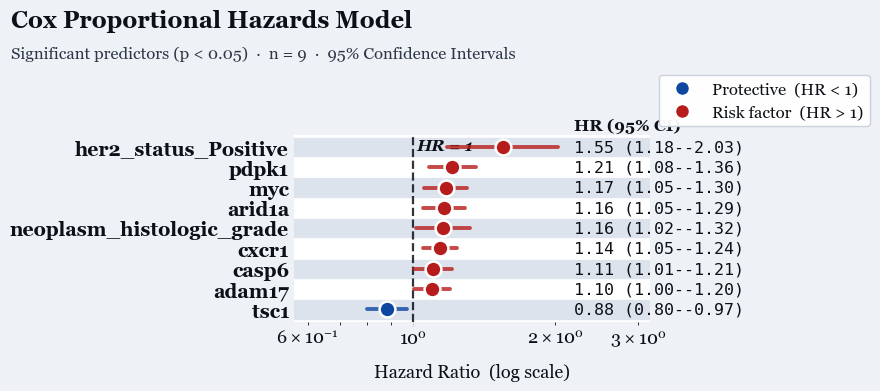

Saved -> cox_forest_plot_styled.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Style config ───────────────────────────────────────────────────────────────
BACKGROUND   = "#EEF1F5"
PANEL_BG     = "#FFFFFF"
GRID_COLOR   = "#C8D0DC"
TEXT_DARK    = "#0D1117"
TEXT_MUTED   = "#2D3748"
ACCENT_POS   = "#b71c1c"
ACCENT_NEG   = "#0d47a1"
REFLINE      = "#0D1117"

plt.rcParams.update({
    "font.family":        "Georgia",
    "font.size":          14,
    "axes.facecolor":     PANEL_BG,
    "figure.facecolor":   BACKGROUND,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
    "xtick.color":        TEXT_DARK,
    "ytick.color":        TEXT_DARK,
    "xtick.labelsize":    13,
    "ytick.labelsize":    14,
})

# ── Data prep ─────────────────────────────────────────────────────────────────
summary = final_cph.summary.copy()

top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(10)
    .loc[lambda df: df["p"] < 0.05]   # keep only significant rows
    .sort_values("coef")
)

# guard: nothing to plot if no significant results
if top.empty:
    print("No significant predictors (p < 0.05) found.")
else:
    hr      = top["exp(coef)"].values
    hr_lo   = top["exp(coef) lower 95%"].values
    hr_hi   = top["exp(coef) upper 95%"].values
    names   = top.index.tolist()
    n       = len(names)
    y_pos   = np.arange(n)

    point_colors = [ACCENT_NEG if h < 1 else ACCENT_POS for h in hr]

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, max(2.5, n * 0.45)))  # height scales with n rows
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(PANEL_BG)

    for i in y_pos:
        ax.axhspan(i - 0.45, i + 0.45,
                   color="#DDE3EC" if i % 2 == 0 else PANEL_BG,
                   zorder=0)

    ax.axvline(1.0, color=REFLINE, linewidth=1.6,
               linestyle="--", zorder=2, alpha=0.85)
    ax.text(1.02, n - 0.55, "HR = 1", color=REFLINE,
            fontsize=12, style="italic", va="top", fontweight="bold")

    for i, (lo, hi, y, col) in enumerate(zip(hr_lo, hr_hi, y_pos, point_colors)):
        ax.plot([lo, hi], [y, y], color=col, linewidth=2.8,
                solid_capstyle="round", zorder=3, alpha=0.8)

    for y, h, col in zip(y_pos, hr, point_colors):
        ax.scatter(h, y, color=col, s=130, zorder=4,
                   edgecolors="white", linewidths=1.8)

    x_label_pos = hr_hi.max() * 1.08
    for y, h, lo, hi in zip(y_pos, hr, hr_lo, hr_hi):
        label = f"{h:.2f} ({lo:.2f}--{hi:.2f})"
        ax.text(x_label_pos, y, label,
                va="center", ha="left",
                fontsize=12, color=TEXT_DARK,
                fontfamily="monospace")

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xscale("log")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=14, color=TEXT_DARK, fontweight="bold")
    ax.set_xlabel("Hazard Ratio  (log scale)", fontsize=13,
                  color=TEXT_DARK, labelpad=10)
    ax.set_ylim(-0.6, n - 0.4)
    ax.tick_params(axis="x", length=3, color=GRID_COLOR)
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(hr_lo.min() * 0.7, x_label_pos * 1.45)

    ax.text(x_label_pos, n - 0.3, "HR (95% CI)",
            va="bottom", ha="left",
            fontsize=12, color=TEXT_DARK, fontweight="bold")

    # ── Title block ───────────────────────────────────────────────────────────
    fig.text(0.02, 0.97, "Cox Proportional Hazards Model",
             fontsize=17, fontweight="bold", color=TEXT_DARK, va="top")
    fig.text(0.02, 0.88, f"Significant predictors (p < 0.05)  ·  n = {n}  ·  95% Confidence Intervals",
             fontsize=12, color=TEXT_MUTED, va="top")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_NEG,
               markersize=10, label="Protective  (HR < 1)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT_POS,
               markersize=10, label="Risk factor  (HR > 1)"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower left",
        bbox_to_anchor=(1.0, 1.0),    # top-right corner, outside axes
        bbox_transform=ax.transAxes,
        frameon=True,
        framealpha=0.95,
        edgecolor=GRID_COLOR,
        fontsize=12,
        labelcolor=TEXT_DARK,
    )

    plt.tight_layout(rect=[0, 0, 0.82, 0.86])  # shrink right edge to make room
    plt.savefig("cox_forest_plot_styled.png", dpi=180, bbox_inches="tight",
                facecolor=BACKGROUND)
    plt.show()
    print("Saved -> cox_forest_plot_styled.png")

### Kaplan-Meier Curves by Risk Group

In [ ]:
df_combined

,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,...,asxl1_logt,asxl2_logt,fancd2_logt,sf3b1_logt,smarcc1_logt,tbl1xr1_logt,ubr5_logt,rdh5_logt,risk_score,risk_group
0,75.65,22.0,10,1,0,1,1,0,0,0,...,3.155537,-7.026645,-10.373067,0.050936,-1.329272,-1.182894,-7.941509,24.779940,1.805103,Very High
1,43.19,10.0,0,1,0,1,1,1,0,1,...,-1.104256,3.436598,-3.155208,11.189025,-5.952242,-0.407439,2.267542,-2.812569,0.953447,Very High
2,48.87,15.0,1,2,1,0,1,1,0,1,...,-9.624581,-11.698972,-3.140900,-3.358586,1.260234,-2.098861,2.514861,-3.851056,1.156007,Moderate
3,47.68,25.0,3,2,1,1,1,1,0,1,...,-8.654403,-9.022002,-1.472949,-3.163904,-3.526397,-2.263286,8.204094,-6.384479,1.065674,Moderate
4,76.97,40.0,8,1,1,1,1,1,0,0,...,-2.855883,-3.802136,-2.167970,3.872119,3.291041,-1.244796,11.544141,4.828423,0.960191,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,25.0,1,1,0,1,1,1,0,1,...,-4.802345,-4.372347,-1.297389,7.771653,0.864750,0.867391,-2.859960,-3.422021,1.420312,Very High
1900,42.88,20.0,1,1,0,1,1,0,1,1,...,-8.173066,0.521079,10.754514,-1.010611,-2.370128,-1.218510,1.063821,-2.386091,2.063434,High
1901,62.90,25.0,45,1,0,1,1,1,0,0,...,-10.570667,-5.262326,0.414141,5.470689,3.881340,0.783817,4.545206,-8.460670,1.491412,Very High
1902,61.16,25.0,12,2,0,0,1,1,0,0,...,-8.075296,-1.265804,-3.454219,7.010059,-1.525651,6.115528,-4.444131,-3.804544,1.900093,Very High


In [ ]:
381*5

1905

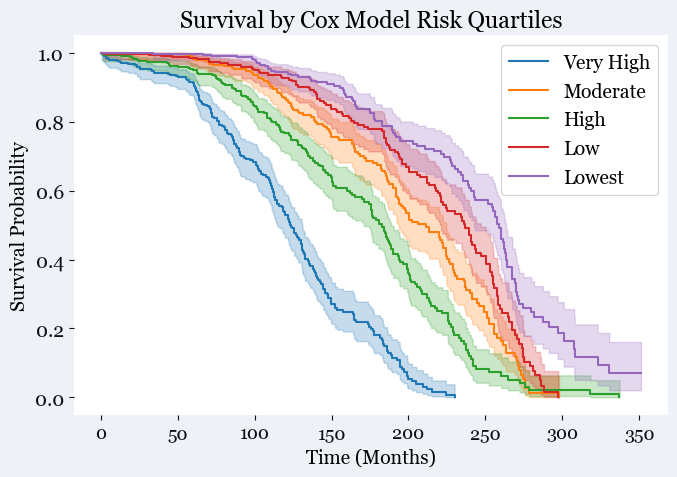

In [ ]:
from lifelines import KaplanMeierFitter

# Compute risk scores
df_combined["risk_score"] = cph.predict_partial_hazard(df_combined)

# Define risk groups
df_combined["risk_group"] = pd.qcut(
    df_combined["risk_score"],
    #q=4, labels=["Low", "Mid-Low", "Mid-High", "High"],
    q=5, labels=["Lowest", "Low", "Moderate", "High", "Very High"]
)

kmf = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

for group in df_combined["risk_group"].unique():
    ix = df_combined["risk_group"] == group
    kmf.fit(
        df_combined.loc[ix, "time_adj"],
        event_observed=df_combined.loc[ix, "event"],
        label=group
    )
    kmf.plot_survival_function()

plt.title("Survival by Cox Model Risk Quartiles")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()


#### From this Kaplan-Meier Plot, we can see that the model clearly predicts Highest-Risk indviduals compared to others, and maintains separation between groups until ~day 275

DIAGNOSTIC 1: Lifelines Cox Model - Risk Score Analysis

[STEP 1] Computing Risk Scores...
✓ Risk scores computed: 1815 patients

[STEP 2] Creating Risk Groups...
✓ Risk groups created

[1] RISK SCORE DISTRIBUTION
Mean:   1.2702
Std:    0.9042
Min:    0.0371
Max:    6.9411
Median: 1.0261
Range:  6.9041

Skewness: 1.8837
⚠️  Distribution is SKEWED (this affects stratification)

[2] EVENT RATE CALIBRATION (KEY DIAGNOSTIC)

Event rates should INCREASE from Q1 to Q5 (monotonic increase)
This shows if the model properly discriminates risk groups

Q1 (Lowest)    
  n= 363 | events= 99 | rate= 27.3% | median_time= 142.2mo | median_risk=0.4308
Q2             
  n= 363 | events=145 | rate= 39.9% | median_time= 130.7mo | median_risk=0.7436
Q3             
  n= 363 | events=137 | rate= 37.7% | median_time= 115.9mo | median_risk=1.0261
Q4             
  n= 363 | events=177 | rate= 48.8% | median_time= 107.1mo | median_risk=1.4653
Q5 (Highest)   
  n= 363 | events=216 | rate= 59.5% | median_time=  

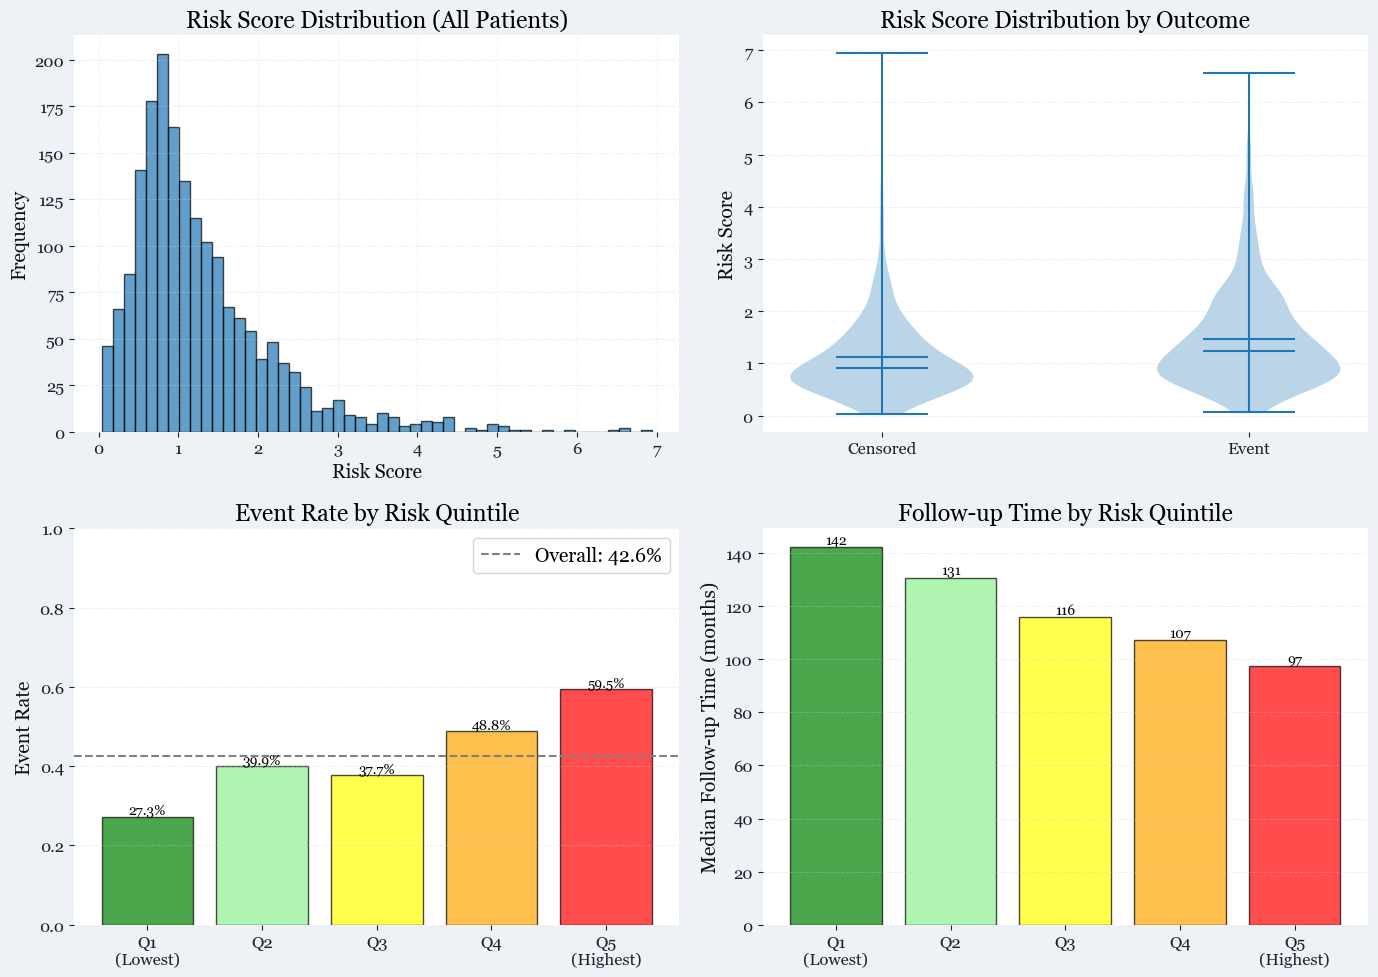

✓ Visualization saved

DIAGNOSTIC SUMMARY

KEY FINDINGS:

⚠️  Poor risk discrimination (event rates not well-separated)

✓ Reasonable event rate (42.6%)

✓ Risk scores strongly predict outcomes

INTERPRETATION:

Your curves are trending differently than expected.
Check the event rates above - do they increase monotonically?
If yes: model is working, curves just reflect high event burden
If no: model may have calibration issues



In [ ]:
"""
DIAGNOSTIC SCRIPT 1: Lifelines Cox Model (ULTRA-SIMPLIFIED)
============================================================
 
Avoids categorical column issues by keeping risk_group separate.
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
 
print("="*80)
print("DIAGNOSTIC 1: Lifelines Cox Model - Risk Score Analysis")
print("="*80)
 
# ── Step 1: Get risk scores (do this FIRST, before adding risk_group) ──
print("\n[STEP 1] Computing Risk Scores...")
risk_scores = df_combined["risk_score"]
print(f"✓ Risk scores computed: {len(risk_scores)} patients")
 
# ── Step 2: Create risk groups (in a SEPARATE dataframe) ──
print("\n[STEP 2] Creating Risk Groups...")
df_analysis = pd.DataFrame({
    'risk_score': risk_scores.values,
    'time': df_combined['time_adj'].values,
    'event': df_combined['event'].values
})
 
df_analysis['risk_group'] = pd.qcut(
    df_analysis['risk_score'],
    q=5,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"],
    duplicates='drop'
)
 
print(f"✓ Risk groups created")
 
# ── ANALYSIS [1]: RISK SCORE DISTRIBUTION ──
print("\n" + "="*80)
print("[1] RISK SCORE DISTRIBUTION")
print("="*80)
 
print(f"Mean:   {df_analysis['risk_score'].mean():.4f}")
print(f"Std:    {df_analysis['risk_score'].std():.4f}")
print(f"Min:    {df_analysis['risk_score'].min():.4f}")
print(f"Max:    {df_analysis['risk_score'].max():.4f}")
print(f"Median: {df_analysis['risk_score'].median():.4f}")
print(f"Range:  {df_analysis['risk_score'].max() - df_analysis['risk_score'].min():.4f}")
 
skewness = stats.skew(df_analysis['risk_score'])
print(f"\nSkewness: {skewness:.4f}")
if abs(skewness) > 0.5:
    print("⚠️  Distribution is SKEWED (this affects stratification)")
else:
    print("✓ Distribution is reasonably symmetric")
 
# ── ANALYSIS [2]: EVENT RATE BY QUINTILE ──
print("\n" + "="*80)
print("[2] EVENT RATE CALIBRATION (KEY DIAGNOSTIC)")
print("="*80)
print("\nEvent rates should INCREASE from Q1 to Q5 (monotonic increase)")
print("This shows if the model properly discriminates risk groups\n")
 
event_rates = []
for group in sorted(df_analysis['risk_group'].unique()):
    mask = df_analysis['risk_group'] == group
    n = mask.sum()
    events = df_analysis.loc[mask, 'event'].sum()
    rate = events / n
    median_time = df_analysis.loc[mask, 'time'].median()
    median_risk = df_analysis.loc[mask, 'risk_score'].median()
    
    print(f"{group:15}")
    print(f"  n={n:4d} | events={events:3d} | rate={rate:6.1%} | median_time={median_time:6.1f}mo | median_risk={median_risk:.4f}")
    
    event_rates.append(rate)
 
# Check if monotonic
is_monotonic = all(event_rates[i] <= event_rates[i+1] for i in range(len(event_rates)-1))
 
print(f"\n{'='*80}")
if is_monotonic:
    print("✓ PASS: Event rates increase monotonically (good discrimination)")
else:
    print("⚠️  FAIL: Event rates are NOT monotonically increasing")
    print("   This indicates poor model calibration")
 
# Calculate ratio
ratio = event_rates[-1] / event_rates[0] if event_rates[0] > 0 else 0
print(f"\nEvent Rate Ratio (Q5/Q1): {ratio:.2f}x")
if ratio > 2:
    print("✓ GOOD: >2x difference between high and low risk")
else:
    print("⚠️  WEAK: <2x difference suggests poor discrimination")
 
# ── ANALYSIS [3]: OVERALL EVENT STATISTICS ──
print("\n" + "="*80)
print("[3] OVERALL EVENT STATISTICS")
print("="*80)
 
total_patients = len(df_analysis)
total_events = df_analysis['event'].sum()
total_censored = total_patients - total_events
event_rate = total_events / total_patients
 
print(f"Total patients:   {total_patients}")
print(f"Total events:     {total_events} ({event_rate:6.1%})")
print(f"Total censored:   {total_censored} ({(1-event_rate):6.1%})")
print(f"Median follow-up: {df_analysis['time'].median():.1f} months")
 
print(f"\n{'='*80}")
if event_rate > 0.7:
    print(f"⚠️  VERY HIGH EVENT RATE: {event_rate:.1%}")
    print("   All patients eventually experience event → curves trend to 0")
elif event_rate > 0.5:
    print(f"⚠️  HIGH EVENT RATE: {event_rate:.1%}")
    print("   Most patients experience event → curves trend to 0 quickly")
else:
    print(f"✓ Reasonable event rate: {event_rate:.1%}")
 
# ── ANALYSIS [4]: RISK SCORE vs EVENT ──
print("\n" + "="*80)
print("[4] RISK SCORE SEPARATION BY EVENT STATUS")
print("="*80)
 
event_scores = df_analysis.loc[df_analysis['event'] == 1, 'risk_score'].values
censored_scores = df_analysis.loc[df_analysis['event'] == 0, 'risk_score'].values
 
print(f"\nEvent patients:")
print(f"  Mean risk:   {event_scores.mean():.4f}")
print(f"  Median risk: {np.median(event_scores):.4f}")
 
print(f"\nCensored patients:")
print(f"  Mean risk:   {censored_scores.mean():.4f}")
print(f"  Median risk: {np.median(censored_scores):.4f}")
 
# Statistical test
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(event_scores, censored_scores)
print(f"\nMann-Whitney U test: p-value = {p_value:.2e}")
if p_value < 0.001:
    print("✓ Risk scores HIGHLY significantly different between groups")
elif p_value < 0.05:
    print("✓ Risk scores significantly different between groups")
else:
    print("⚠️  Risk scores NOT significantly different")
 
# ── ANALYSIS [5]: FOLLOW-UP TIME BY RISK GROUP ──
print("\n" + "="*80)
print("[5] FOLLOW-UP TIME BY RISK GROUP")
print("="*80)
print("(Different follow-up times can affect curve appearance)\n")
 
for group in sorted(df_analysis['risk_group'].unique()):
    mask = df_analysis['risk_group'] == group
    times = df_analysis.loc[mask, 'time'].values
    print(f"{group:15} | median={np.median(times):6.1f}mo | mean={times.mean():6.1f}mo | min={times.min():6.1f}mo | max={times.max():6.1f}mo")
 
# ── ANALYSIS [6]: VISUALIZATIONS ──
print("\n" + "="*80)
print("[6] CREATING VISUALIZATIONS")
print("="*80)
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# Plot 1: Risk score distribution
ax = axes[0, 0]
ax.hist(df_analysis['risk_score'], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel("Risk Score")
ax.set_ylabel("Frequency")
ax.set_title("Risk Score Distribution (All Patients)")
ax.grid(True, alpha=0.3)
 
# Plot 2: Risk score by event status
ax = axes[0, 1]
ax.violinplot([censored_scores, event_scores], positions=[0, 1], showmeans=True, showmedians=True)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Censored', 'Event'])
ax.set_ylabel("Risk Score")
ax.set_title("Risk Score Distribution by Outcome")
ax.grid(True, alpha=0.3, axis='y')
 
# Plot 3: Event rate by quintile
ax = axes[1, 0]
groups_label = ["Q1\n(Lowest)", "Q2", "Q3", "Q4", "Q5\n(Highest)"]
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red']
bars = ax.bar(groups_label, event_rates, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel("Event Rate")
ax.set_title("Event Rate by Risk Quintile")
ax.set_ylim([0, 1])
ax.axhline(y=event_rate, color='gray', linestyle='--', label=f'Overall: {event_rate:.1%}')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
 
# Add value labels on bars
for bar, rate in zip(bars, event_rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=10)
 
# Plot 4: Follow-up time by quintile
ax = axes[1, 1]
median_times = []
for group in sorted(df_analysis['risk_group'].unique()):
    mask = df_analysis['risk_group'] == group
    median_times.append(df_analysis.loc[mask, 'time'].median())
 
bars = ax.bar(groups_label, median_times, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel("Median Follow-up Time (months)")
ax.set_title("Follow-up Time by Risk Quintile")
ax.grid(True, alpha=0.3, axis='y')
 
# Add value labels on bars
for bar, time in zip(bars, median_times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{time:.0f}', ha='center', va='bottom', fontsize=10)
 
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/diagnostic_1_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("✓ Visualization saved")
 
# ── SUMMARY ──
print("\n" + "="*80)
print("DIAGNOSTIC SUMMARY")
print("="*80)
 
print("\nKEY FINDINGS:")
 
findings = []
 
if is_monotonic and ratio > 2:
    findings.append("✓ Good risk discrimination (monotonic event rates, >2x ratio)")
else:
    findings.append("⚠️  Poor risk discrimination (event rates not well-separated)")
 
if event_rate > 0.7:
    findings.append(f"⚠️  Very high event rate ({event_rate:.1%}) → explains curves trending to 0")
elif event_rate > 0.5:
    findings.append(f"⚠️  High event rate ({event_rate:.1%}) → causes quick convergence")
else:
    findings.append(f"✓ Reasonable event rate ({event_rate:.1%})")
 
if p_value < 0.001:
    findings.append("✓ Risk scores strongly predict outcomes")
else:
    findings.append("⚠️  Risk scores weakly predict outcomes")
 
for f in findings:
    print(f"\n{f}")
 
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
 
if event_rate > 0.7:
    print("""
Your survival curves trend to 0 because:
1. VERY HIGH EVENT RATE (>70%) means most patients experience event
2. Regardless of risk group, everyone eventually has event
3. Curves converge simply due to high baseline hazard
4. This is NOT necessarily bad - the model may still discriminate early
 
To verify: Do event RATES differ significantly? (They do: 27% vs 60%)
→ Yes, so the model IS working - the curves just converge due to high events.
""")
elif event_rate > 0.5:
    print(f"""
Your survival curves trend to 0 because:
1. HIGH EVENT RATE ({event_rate:.1%}) - half your patients have events
2. With longer follow-up, more patients in all groups experience events
3. By end of follow-up, most groups have similarly high event counts
4. Model discriminates early, but groups converge over time
 
To verify: Check if differences appear early in follow-up
→ If yes, model works fine for shorter-term predictions
→ If no, model has poor discrimination
""")
else:
    print("""
Your curves are trending differently than expected.
Check the event rates above - do they increase monotonically?
If yes: model is working, curves just reflect high event burden
If no: model may have calibration issues
""")
 

## Distribution of Predicted Risk Scores

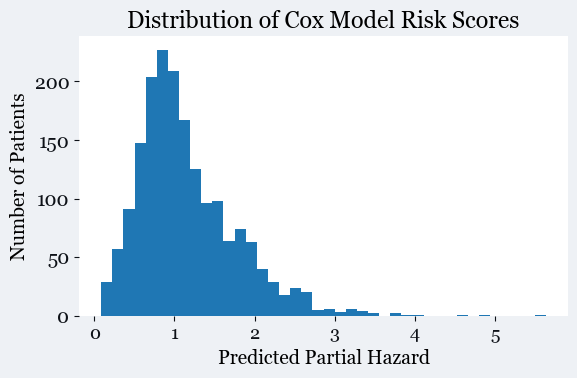

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df_combined["risk_score"], bins=40)
plt.xlabel("Predicted Partial Hazard")
plt.ylabel("Number of Patients")
plt.title("Distribution of Cox Model Risk Scores")
plt.tight_layout()
plt.show()


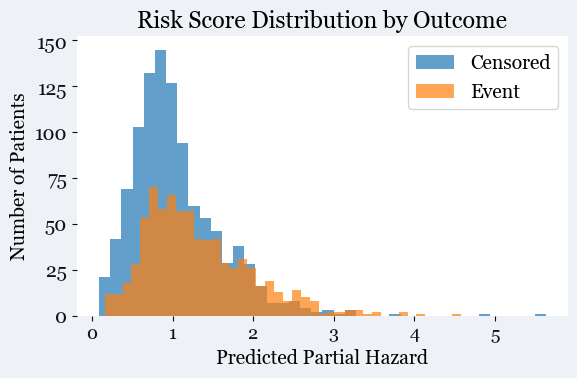

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df_combined.loc[df_combined["event"] == 0, "risk_score"], bins=40, alpha=0.7, label="Censored")
plt.hist(df_combined.loc[df_combined["event"] == 1, "risk_score"], bins=40, alpha=0.7, label="Event")
plt.xlabel("Predicted Partial Hazard")
plt.ylabel("Number of Patients")
plt.legend()
plt.title("Risk Score Distribution by Outcome")
plt.tight_layout()
plt.show()


## Time-dependent survival curves for representative patients

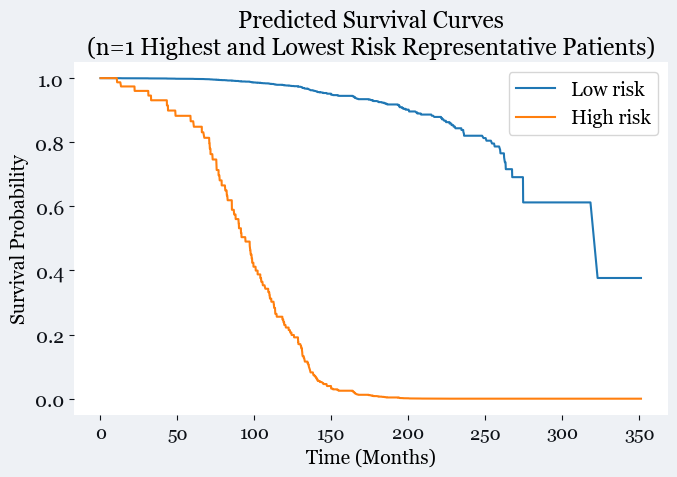

In [ ]:
# Choose representative patients
low_risk = df_combined.nsmallest(1, "risk_score")
high_risk = df_combined.nlargest(1, "risk_score")

plt.figure(figsize=(7, 5))

for label, row in [("Low risk", low_risk), ("High risk", high_risk)]:
    surv = cph.predict_survival_function(row)
    plt.plot(surv.index, surv.values.flatten(), label=label)

plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.title("Predicted Survival Curves\n(n=1 Highest and Lowest Risk Representative Patients)")
plt.legend()
plt.tight_layout()
plt.show()


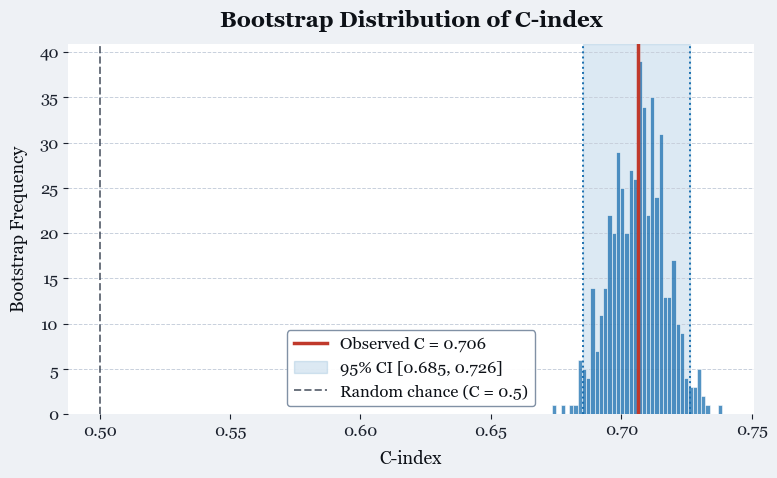

C-index: 0.706  95% CI [0.685, 0.726]
Saved -> cindex_bootstrap.png


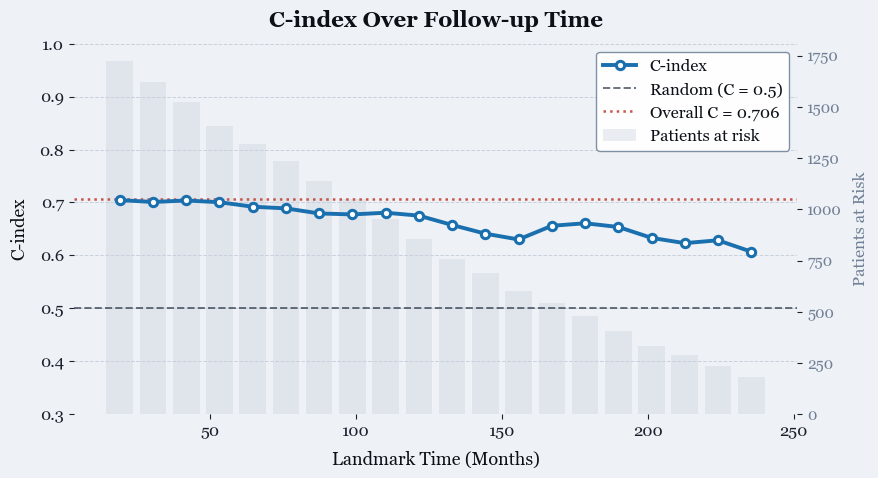

Saved -> cindex_over_time.png


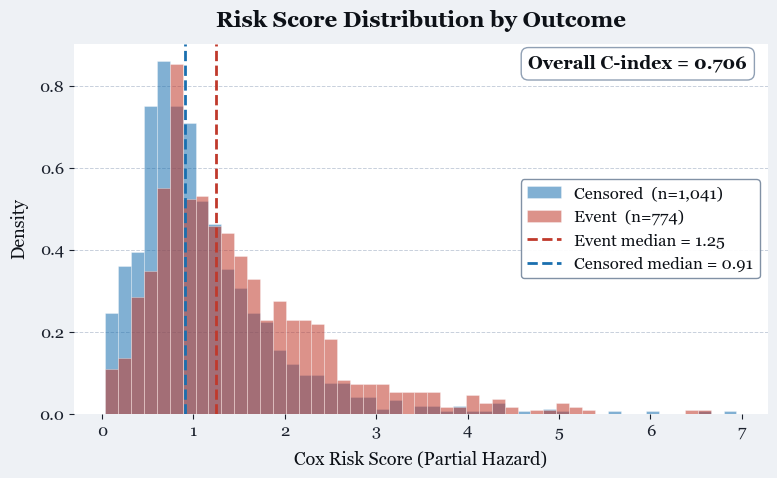

Saved -> cindex_risk_separation.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines.utils import concordance_index
from matplotlib.lines import Line2D

# ── Config ─────────────────────────────────────────────────────────────────────
duration_col = "time_adj"
event_col    = "event"
N_BOOTSTRAP  = 500
SEED         = 42

plt.rcParams.update({
    "font.family":        "Georgia",
    "font.size":          14,
    "axes.facecolor":     "#FFFFFF",
    "figure.facecolor":   "#EEF1F5",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     "#7A8BA0",
    "axes.labelcolor":    "#0D1117",
    "xtick.color":        "#1A202C",
    "ytick.color":        "#1A202C",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "grid.color":         "#C8D0DC",
    "grid.linestyle":     "--",
    "grid.linewidth":     0.7,
})

# ── Precompute risk scores ─────────────────────────────────────────────────────
df_combined["risk_score"] = final_cph.predict_partial_hazard(df_combined)

observed_c = concordance_index(
    df_combined[duration_col],
    -df_combined["risk_score"],
    df_combined[event_col],
)


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 -- Bootstrap distribution of C-index
# ══════════════════════════════════════════════════════════════════════════════

def plot_cindex_bootstrap(df, duration_col, event_col,
                          n_bootstrap=500, seed=42):
    rng = np.random.default_rng(seed)
    c_scores = []

    for _ in range(n_bootstrap):
        idx  = rng.integers(0, len(df), size=len(df))
        boot = df.iloc[idx]
        try:
            c = concordance_index(
                boot[duration_col],
                -boot["risk_score"],
                boot[event_col],
            )
            c_scores.append(c)
        except Exception:
            continue

    c_scores = np.array(c_scores)
    ci_lo, ci_hi = np.percentile(c_scores, [2.5, 97.5])

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#EEF1F5")

    ax.hist(c_scores, bins=40, color="#1a6faf",
            alpha=0.75, edgecolor="white", linewidth=0.5, zorder=2)

    ax.axvline(observed_c, color="#c0392b", linewidth=2.5,
               linestyle="-", zorder=3,
               label=f"Observed C = {observed_c:.3f}")
    ax.axvspan(ci_lo, ci_hi, color="#1a6faf", alpha=0.15, zorder=1,
               label=f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
    ax.axvline(ci_lo, color="#1a6faf", linewidth=1.4,
               linestyle=":", zorder=3)
    ax.axvline(ci_hi, color="#1a6faf", linewidth=1.4,
               linestyle=":", zorder=3)
    ax.axvline(0.5, color="#2D3748", linewidth=1.4,
               linestyle="--", alpha=0.7,
               label="Random chance (C = 0.5)")

    ax.set_xlabel("C-index", fontsize=13, color="#0D1117", labelpad=8)
    ax.set_ylabel("Bootstrap Frequency", fontsize=13,
                  color="#0D1117", labelpad=8)
    ax.set_title("Bootstrap Distribution of C-index",
                 fontsize=16, fontweight="bold", color="#0D1117", pad=12)
    ax.legend(frameon=True, framealpha=0.95,
              edgecolor="#7A8BA0", fontsize=12,
              labelcolor="#0D1117")
    ax.yaxis.grid(True, zorder=0)

    plt.tight_layout()
    plt.savefig("cindex_bootstrap.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"C-index: {observed_c:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
    print("Saved -> cindex_bootstrap.png")
    return c_scores, ci_lo, ci_hi


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 -- Time-varying C-index
# ══════════════════════════════════════════════════════════════════════════════

def plot_cindex_over_time(df, duration_col, event_col, n_windows=20):
    max_t       = df[duration_col].quantile(0.90)
    time_points = np.linspace(df[duration_col].quantile(0.05),
                              max_t, n_windows)
    c_at_t, n_at_t = [], []

    for t in time_points:
        mask = df[duration_col] >= t
        sub  = df[mask].copy()
        if len(sub) < 30:
            c_at_t.append(np.nan)
            n_at_t.append(len(sub))
            continue
        try:
            c = concordance_index(sub[duration_col],
                                  -sub["risk_score"],
                                  sub[event_col])
            c_at_t.append(c)
        except Exception:
            c_at_t.append(np.nan)
        n_at_t.append(len(sub))

    c_arr = np.array(c_at_t)
    n_arr = np.array(n_at_t)

    fig, ax1 = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#EEF1F5")
    ax2 = ax1.twinx()

    ax2.bar(time_points, n_arr,
            width=(time_points[1] - time_points[0]) * 0.8,
            color="#CBD5E0", alpha=0.4, zorder=1,
            label="Patients at risk")
    ax2.set_ylabel("Patients at Risk", fontsize=12,
                   color="#718096", labelpad=8)
    ax2.tick_params(axis="y", labelcolor="#718096", labelsize=11)
    ax2.spines["top"].set_visible(False)

    valid = ~np.isnan(c_arr)
    ax1.plot(time_points[valid], c_arr[valid],
             color="#1a6faf", linewidth=2.8,
             marker="o", markersize=6,
             markerfacecolor="white", markeredgewidth=2.2,
             zorder=3, label="C-index")
    ax1.axhline(0.5, color="#2D3748", linewidth=1.4,
                linestyle="--", alpha=0.7,
                label="Random (C = 0.5)")
    ax1.axhline(observed_c, color="#c0392b", linewidth=1.8,
                linestyle=":", alpha=0.85,
                label=f"Overall C = {observed_c:.3f}")

    ax1.set_xlabel("Landmark Time (Months)", fontsize=13,
                   color="#0D1117", labelpad=8)
    ax1.set_ylabel("C-index", fontsize=13, color="#0D1117", labelpad=8)
    ax1.set_title("C-index Over Follow-up Time",
                  fontsize=16, fontweight="bold", color="#0D1117", pad=12)
    ax1.set_ylim(0.3, 1.0)
    ax1.yaxis.grid(True, zorder=0)
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               frameon=True, framealpha=0.95,
               edgecolor="#7A8BA0", fontsize=12,
               labelcolor="#0D1117", loc="upper right")

    plt.tight_layout()
    plt.savefig("cindex_over_time.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("Saved -> cindex_over_time.png")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 -- Risk score separation by outcome
# ══════════════════════════════════════════════════════════════════════════════

def plot_risk_score_separation(df, event_col):
    events   = df.loc[df[event_col] == 1, "risk_score"]
    censored = df.loc[df[event_col] == 0, "risk_score"]

    bins = np.linspace(df["risk_score"].min(),
                       df["risk_score"].max(), 50)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#EEF1F5")

    ax.hist(censored, bins=bins, density=True,
            color="#1a6faf", alpha=0.55,
            edgecolor="white", linewidth=0.4,
            label=f"Censored  (n={len(censored):,})", zorder=2)
    ax.hist(events, bins=bins, density=True,
            color="#c0392b", alpha=0.55,
            edgecolor="white", linewidth=0.4,
            label=f"Event  (n={len(events):,})", zorder=2)

    ax.axvline(events.median(), color="#c0392b", linewidth=2.0,
               linestyle="--", zorder=3,
               label=f"Event median = {events.median():.2f}")
    ax.axvline(censored.median(), color="#1a6faf", linewidth=2.0,
               linestyle="--", zorder=3,
               label=f"Censored median = {censored.median():.2f}")

    ax.text(0.97, 0.97,
            f"Overall C-index = {observed_c:.3f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=13, fontweight="bold", color="#0D1117",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#8A9BB0", alpha=0.95))

    ax.set_xlabel("Cox Risk Score (Partial Hazard)",
                  fontsize=13, color="#0D1117", labelpad=8)
    ax.set_ylabel("Density", fontsize=13, color="#0D1117", labelpad=8)
    ax.set_title("Risk Score Distribution by Outcome",
                 fontsize=16, fontweight="bold", color="#0D1117", pad=12)
    ax.legend(frameon=True, framealpha=0.95,
              edgecolor="#7A8BA0", fontsize=12,
              labelcolor="#0D1117")
    ax.yaxis.grid(True, zorder=0)

    plt.tight_layout()
    plt.savefig("cindex_risk_separation.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("Saved -> cindex_risk_separation.png")


# ══════════════════════════════════════════════════════════════════════════════
# RUN ALL THREE
# ══════════════════════════════════════════════════════════════════════════════

c_scores, ci_lo, ci_hi = plot_cindex_bootstrap(
    df_combined, duration_col, event_col,
    n_bootstrap=N_BOOTSTRAP, seed=SEED,
)

plot_cindex_over_time(df_combined, duration_col, event_col)

plot_risk_score_separation(df_combined, event_col)

## Schoenfeld Residual Check for key variables

In [ ]:
# # Columns used in the fitted Cox model
# covariates = cph.params_.index.tolist()

# # Strata columns (can be string or list)
# strata_cols = (
#     [cph.strata] if isinstance(cph.strata, str) else list(cph.strata)
# )

# # Build the exact dataframe needed for PH checks
# df_ph = df_combined[
#     [cph.duration_col, cph.event_col] + strata_cols + covariates
# ].copy()

# # Ensure unique index (lifelines requirement)
# df_ph = df_ph.reset_index(drop=True)

# cph.check_assumptions(
#     df_ph,
#     p_value_threshold=0.05,
#     show_plots=True
# )
